In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install torch torchvision torchaudio
!pip install transformers sentence-transformers
!pip install kaggle
!pip install torch-xla -f https://storage.googleapis.com/libtpu-releases/index.html

Looking in links: https://storage.googleapis.com/libtpu-releases/index.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 MB 11.0 MB/s eta 0:00:00


In [4]:
import kagglehub

path = kagglehub.dataset_download("simhadrisadaram/mimic-cxr-dataset")

print("Path to dataset files:", path)

!wget -r -N -c -np --user simplyviraj --ask-password -P {drive_base_dir} -O {chexpert_csv_path} https://physionet.org/files/mimic-cxr-jpg/2.1.0/mimic-cxr-2.0.0-chexpert.csv.gz


Using Colab cache for faster access to the 'mimic-cxr-dataset' dataset.
Path to dataset files: /kaggle/input/mimic-cxr-dataset
will be placed in the single file you specified.

for details.

Password for user ‘simplyviraj’: 
--2026-05-01 08:22:53--  https://physionet.org/files/mimic-cxr-jpg/2.1.0/mimic-cxr-2.0.0-chexpert.csv.gz
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 401 Unauthorized
Authentication selected: Basic realm="PhysioNet", charset="UTF-8"
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2097855 (2.0M) [application/gzip]
Saving to: ‘{chexpert_csv_path}’

h}                  100%[===================>]   2.00M   212KB/s    in 9.8s    

2026-05-01 08:23:04 (209 KB/s) - ‘{chexpert_csv_path}’ saved [2097855/2097855]

FINISHED --2026-05-01 08:23:04--
Total wall clock time: 17s
Downloaded: 1 files, 

In [5]:
print('Files in current directory:')
!ls -F

Files in current directory:
{chexpert_csv_path}  drive/  sample_data/


In [6]:
print(f'Files in Kaggle dataset directory: {path}')
!ls -F {path}

Files in Kaggle dataset directory: /kaggle/input/mimic-cxr-dataset
mimic_cxr_aug_train.csv  mimic_cxr_aug_validate.csv  official_data_iccv_final/


In [7]:
import pandas as pd

train_df_path = f'{path}/mimic_cxr_aug_train.csv'
train_df = pd.read_csv(train_df_path)
display(train_df[:10])

,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment
0,0,0,10000032,['files/p10/p10000032/s50414267/02aa804e-bde0a...,"['PA', 'LATERAL', 'AP']",['files/p10/p10000032/s53911762/68b5c4b1-227d0...,['files/p10/p10000032/s50414267/02aa804e-bde0a...,['files/p10/p10000032/s50414267/174413ec-4ec4c...,"['Findings: There is no focal consolidation, p...","['Findings: There is no focus, pleural effusio..."
1,1,1,10000764,['files/p10/p10000764/s57375967/096052b7-d256d...,"['AP', 'LATERAL']",['files/p10/p10000764/s57375967/096052b7-d256d...,[],['files/p10/p10000764/s57375967/b79e55c3-735ce...,['Findings: PA and lateral views of the chest ...,['Finds: PA and lateral view of the breast int...
2,2,2,10000898,['files/p10/p10000898/s50771383/0c4eb1e1-b8019...,"['LATERAL', 'PA']",[],['files/p10/p10000898/s50771383/2a280266-c8bae...,['files/p10/p10000898/s50771383/0c4eb1e1-b8019...,['Findings: PA and lateral views of the chest ...,['Finds: PA and side view of the chest provide...
3,3,3,10000935,['files/p10/p10000935/s50578979/d0b71acc-b5a62...,"['AP', 'LATERAL', 'LL', 'PA']",['files/p10/p10000935/s50578979/d0b71acc-b5a62...,['files/p10/p10000935/s55697293/c50494f1-90e2b...,['files/p10/p10000935/s51178377/3be619d1-506a6...,['Findings: Lung volumes remain low. There ar...,['Results: Pulmonary volumes remain low. There...
4,4,4,10000980,['files/p10/p10000980/s50985099/6ad03ed1-97ee1...,"['PA', 'LL', 'AP', 'LATERAL']",['files/p10/p10000980/s51967283/943486a3-b3fa9...,['files/p10/p10000980/s50985099/6ad03ed1-97ee1...,['files/p10/p10000980/s54577367/96f9a77c-59b47...,['Findings: Impression: Compared to chest rad...,['Findings: Impression: Compared to the thorac...
5,5,5,10001038,['files/p10/p10001038/s58224503/28fad2ac-d6001...,"['PA', 'LATERAL']",[],['files/p10/p10001038/s58224503/28fad2ac-d6001...,['files/p10/p10001038/s58224503/f3e86afd-437eb...,['Findings: PA and lateral views of the chest ...,['Findings: PA and side-view of the chest prov...
6,6,6,10001122,['files/p10/p10001122/s53447138/8039752c-2ea66...,"['nan', 'AP', 'LATERAL']",['files/p10/p10001122/s53957785/07b9ddda-9a4a1...,[],['files/p10/p10001122/s53957785/9d0b174f-274aa...,['Findings: Impression: The lung volumes are ...,['Findings: Impression: Lung volumes are norma...
7,7,7,10001176,['files/p10/p10001176/s53186264/1fe73f8e-036bd...,"['PA', 'LATERAL', 'LL']",[],['files/p10/p10001176/s53186264/1fe73f8e-036bd...,['files/p10/p10001176/s53186264/c0b72282-4bf7a...,['Findings: The heart is normal in size. The ...,['Findings: The heart is normal in size. The m...
8,8,8,10001217,['files/p10/p10001217/s52067803/a917c883-720a5...,"['PA', 'LATERAL', 'AP']",['files/p10/p10001217/s58913004/5e54fc9c-37c49...,['files/p10/p10001217/s52067803/a917c883-720a5...,['files/p10/p10001217/s52067803/ab111843-fd3b8...,['Findings: There is mild left base atelectasi...,['Results: On the frontal view there is a slig...
9,9,9,10001401,['files/p10/p10001401/s50225296/0009a9fb-eb905...,"['AP', 'LATERAL', 'PA', 'LL']",['files/p10/p10001401/s50225296/0009a9fb-eb905...,['files/p10/p10001401/s51065211/8061113f-c019f...,['files/p10/p10001401/s51065211/1af1b768-31250...,['Findings: Impression: No previous images. ...,['Results: Impression: No previous images. Nas...


In [8]:
print('Missing values in each column:')
print(train_df.isnull().sum())

Missing values in each column:
Unnamed: 0.1    0
Unnamed: 0      0
subject_id      0
image           0
view            0
AP              0
PA              0
Lateral         0
text            0
text_augment    0
dtype: int64


In [9]:
print("Count of empty lists in 'AP' column:", train_df[train_df['AP'].apply(lambda x: len(x) == 0)].shape[0])
print("Count of empty lists in 'PA' column:", train_df[train_df['PA'].apply(lambda x: len(x) == 0)].shape[0])

Count of empty lists in 'AP' column: 0
Count of empty lists in 'PA' column: 0


In [10]:
import ast

# Convert string representation of lists to actual lists
for col in ['image', 'view', 'AP', 'PA', 'Lateral', 'text', 'text_augment']:
    train_df[col] = train_df[col].apply(ast.literal_eval)

In [11]:
print("Count of actual empty lists in 'AP' column after conversion:", train_df[train_df['AP'].apply(lambda x: len(x) == 0)].shape[0])
print("Count of actual empty lists in 'PA' column after conversion:", train_df[train_df['PA'].apply(lambda x: len(x) == 0)].shape[0])
print("Count of actual empty lists in 'Lateral' column after conversion:", train_df[train_df['Lateral'].apply(lambda x: len(x) == 0)].shape[0])
print("Count of actual empty lists in 'image' column after conversion:", train_df[train_df['image'].apply(lambda x: len(x) == 0)].shape[0])

# Display some rows where 'AP' or 'PA' is an empty list to confirm
print('\nRows with empty AP or PA lists:')
display(train_df[(train_df['AP'].apply(lambda x: len(x) == 0)) | (train_df['PA'].apply(lambda x: len(x) == 0))].head())

Count of actual empty lists in 'AP' column after conversion: 31612
Count of actual empty lists in 'PA' column after conversion: 19504
Count of actual empty lists in 'Lateral' column after conversion: 20060
Count of actual empty lists in 'image' column after conversion: 0

Rows with empty AP or PA lists:


,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment
1,1,1,10000764,[files/p10/p10000764/s57375967/096052b7-d256dc...,"[AP, LATERAL]",[files/p10/p10000764/s57375967/096052b7-d256dc...,[],[files/p10/p10000764/s57375967/b79e55c3-735ce5...,[Findings: PA and lateral views of the chest p...,[Finds: PA and lateral view of the breast inte...
2,2,2,10000898,[files/p10/p10000898/s50771383/0c4eb1e1-b80190...,"[LATERAL, PA]",[],[files/p10/p10000898/s50771383/2a280266-c8bae1...,[files/p10/p10000898/s50771383/0c4eb1e1-b80190...,[Findings: PA and lateral views of the chest p...,[Finds: PA and side view of the chest provided...
5,5,5,10001038,[files/p10/p10001038/s58224503/28fad2ac-d60012...,"[PA, LATERAL]",[],[files/p10/p10001038/s58224503/28fad2ac-d60012...,[files/p10/p10001038/s58224503/f3e86afd-437eb8...,[Findings: PA and lateral views of the chest p...,[Findings: PA and side-view of the chest provi...
6,6,6,10001122,[files/p10/p10001122/s53447138/8039752c-2ea661...,"[nan, AP, LATERAL]",[files/p10/p10001122/s53957785/07b9ddda-9a4a1e...,[],[files/p10/p10001122/s53957785/9d0b174f-274aad...,[Findings: Impression: The lung volumes are n...,[Findings: Impression: Lung volumes are normal...
7,7,7,10001176,[files/p10/p10001176/s53186264/1fe73f8e-036bd2...,"[PA, LATERAL, LL]",[],[files/p10/p10001176/s53186264/1fe73f8e-036bd2...,[files/p10/p10001176/s53186264/c0b72282-4bf7ad...,[Findings: The heart is normal in size. The m...,[Findings: The heart is normal in size. The me...


### Descriptive Statistics for Numerical Columns

In [12]:
display(train_df.describe())

,Unnamed: 0.1,Unnamed: 0,subject_id
count,64586.00000,64586.000000,6.458600e+04
mean,32292.50000,32686.232527,1.501378e+07
std,18644.51658,18877.306159,2.884796e+06
min,0.00000,0.000000,1.000003e+07
25%,16146.25000,16334.250000,1.251292e+07
50%,32292.50000,32679.500000,1.501916e+07
75%,48438.75000,49035.750000,1.752156e+07
max,64585.00000,65378.000000,1.999999e+07


In [13]:
print('Missing values across the entire dataset:')
print(train_df.isnull().sum())

Missing values across the entire dataset:
Unnamed: 0.1    0
Unnamed: 0      0
subject_id      0
image           0
view            0
AP              0
PA              0
Lateral         0
text            0
text_augment    0
dtype: int64


In [14]:
train_df[:10]

,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment
0,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion..."
1,1,1,10000764,[files/p10/p10000764/s57375967/096052b7-d256dc...,"[AP, LATERAL]",[files/p10/p10000764/s57375967/096052b7-d256dc...,[],[files/p10/p10000764/s57375967/b79e55c3-735ce5...,[Findings: PA and lateral views of the chest p...,[Finds: PA and lateral view of the breast inte...
2,2,2,10000898,[files/p10/p10000898/s50771383/0c4eb1e1-b80190...,"[LATERAL, PA]",[],[files/p10/p10000898/s50771383/2a280266-c8bae1...,[files/p10/p10000898/s50771383/0c4eb1e1-b80190...,[Findings: PA and lateral views of the chest p...,[Finds: PA and side view of the chest provided...
3,3,3,10000935,[files/p10/p10000935/s50578979/d0b71acc-b5a620...,"[AP, LATERAL, LL, PA]",[files/p10/p10000935/s50578979/d0b71acc-b5a620...,[files/p10/p10000935/s55697293/c50494f1-90e2bf...,[files/p10/p10000935/s51178377/3be619d1-506a66...,[Findings: Lung volumes remain low. There are...,[Results: Pulmonary volumes remain low. There ...
4,4,4,10000980,[files/p10/p10000980/s50985099/6ad03ed1-97ee17...,"[PA, LL, AP, LATERAL]",[files/p10/p10000980/s51967283/943486a3-b3fa9f...,[files/p10/p10000980/s50985099/6ad03ed1-97ee17...,[files/p10/p10000980/s54577367/96f9a77c-59b47d...,[Findings: Impression: Compared to chest radi...,[Findings: Impression: Compared to the thoraci...
5,5,5,10001038,[files/p10/p10001038/s58224503/28fad2ac-d60012...,"[PA, LATERAL]",[],[files/p10/p10001038/s58224503/28fad2ac-d60012...,[files/p10/p10001038/s58224503/f3e86afd-437eb8...,[Findings: PA and lateral views of the chest p...,[Findings: PA and side-view of the chest provi...
6,6,6,10001122,[files/p10/p10001122/s53447138/8039752c-2ea661...,"[nan, AP, LATERAL]",[files/p10/p10001122/s53957785/07b9ddda-9a4a1e...,[],[files/p10/p10001122/s53957785/9d0b174f-274aad...,[Findings: Impression: The lung volumes are n...,[Findings: Impression: Lung volumes are normal...
7,7,7,10001176,[files/p10/p10001176/s53186264/1fe73f8e-036bd2...,"[PA, LATERAL, LL]",[],[files/p10/p10001176/s53186264/1fe73f8e-036bd2...,[files/p10/p10001176/s53186264/c0b72282-4bf7ad...,[Findings: The heart is normal in size. The m...,[Findings: The heart is normal in size. The me...
8,8,8,10001217,[files/p10/p10001217/s52067803/a917c883-720a5b...,"[PA, LATERAL, AP]",[files/p10/p10001217/s58913004/5e54fc9c-37c498...,[files/p10/p10001217/s52067803/a917c883-720a5b...,[files/p10/p10001217/s52067803/ab111843-fd3b88...,[Findings: There is mild left base atelectasis...,[Results: On the frontal view there is a sligh...
9,9,9,10001401,[files/p10/p10001401/s50225296/0009a9fb-eb905e...,"[AP, LATERAL, PA, LL]",[files/p10/p10001401/s50225296/0009a9fb-eb905e...,[files/p10/p10001401/s51065211/8061113f-c019f3...,[files/p10/p10001401/s51065211/1af1b768-31250d...,[Findings: Impression: No previous images. N...,[Results: Impression: No previous images. Naso...


Image file not found: /kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/p10/p10000935/s55697293/c50494f1-90e2bff5-e9189550-1a4562fd-6ab5204c.jpg


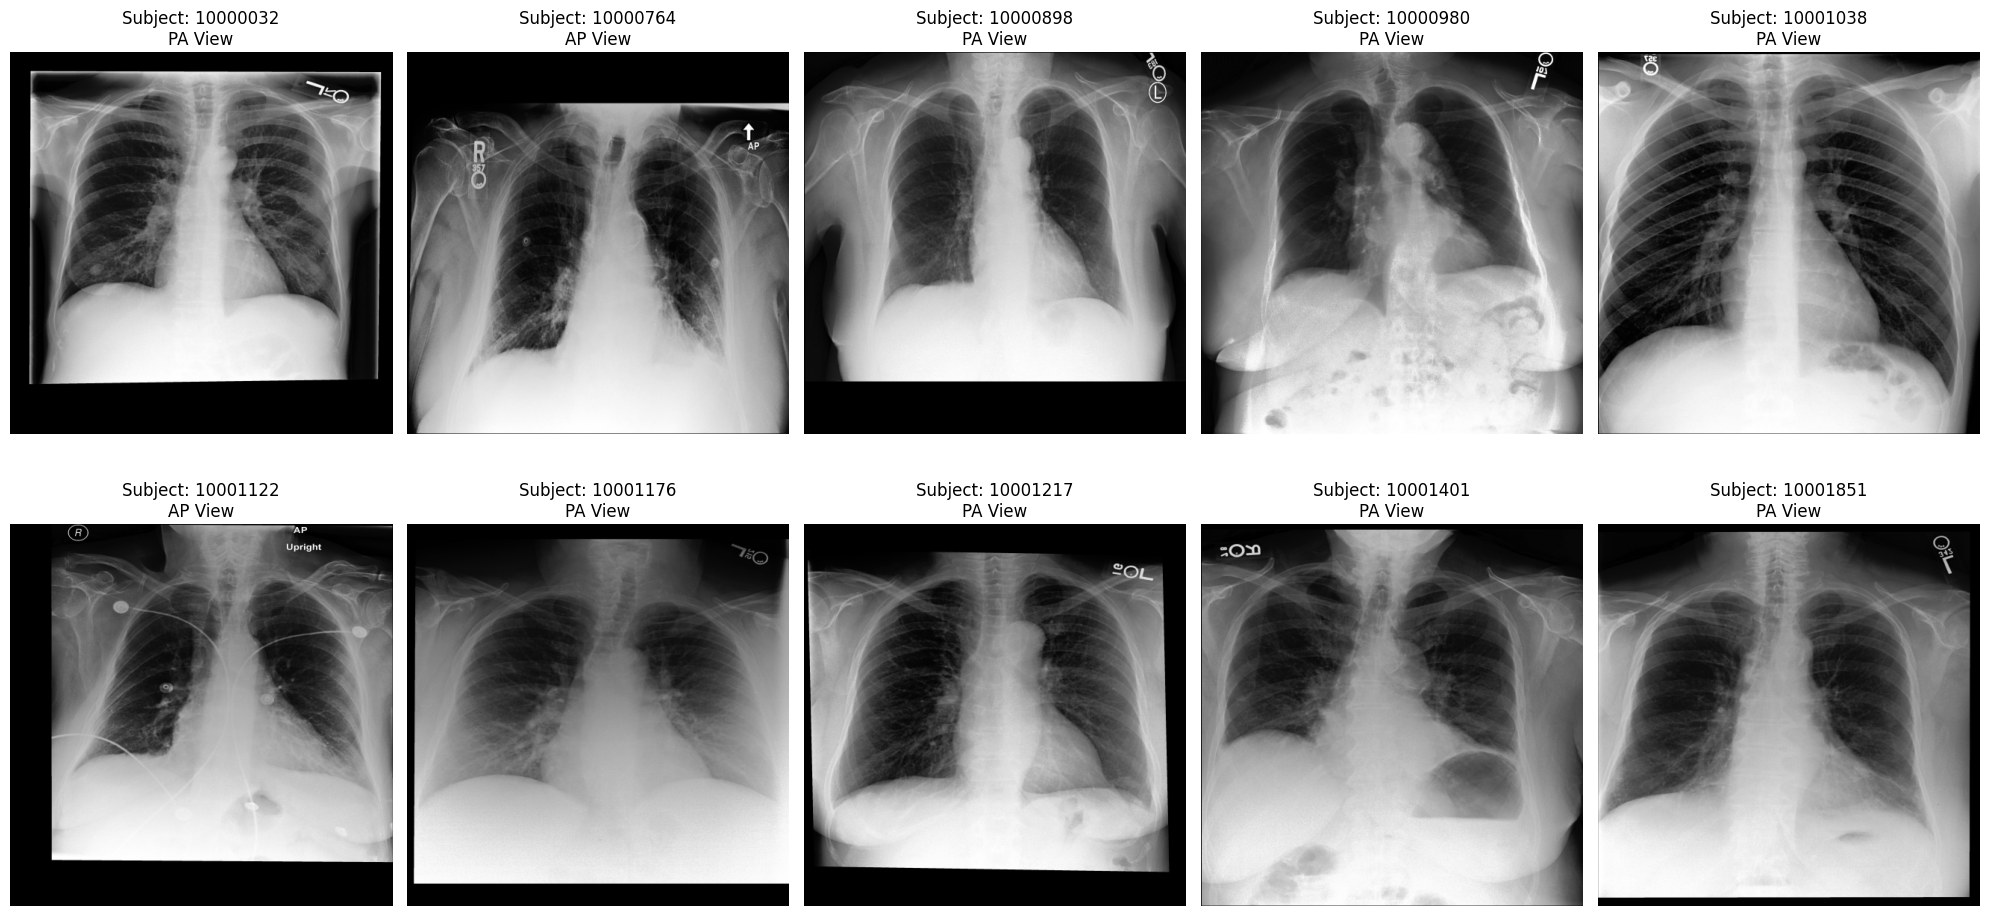

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import os

num_images_to_display = 10
image_base_path = '/kaggle/input/mimic-cxr-dataset/official_data_iccv_final'

plt.figure(figsize=(20, 10))

# Keep track of how many images we've displayed
displayed_count = 0

for index, row in train_df.iterrows():
    if displayed_count >= num_images_to_display:
        break

    # Prioritize PA or AP images
    image_path_relative = None
    image_view = ""

    if row['PA'] and len(row['PA']) > 0:
        image_path_relative = row['PA'][0]
        image_view = "PA View"
    elif row['AP'] and len(row['AP']) > 0:
        image_path_relative = row['AP'][0]
        image_view = "AP View"
    elif row['Lateral'] and len(row['Lateral']) > 0:
        image_path_relative = row['Lateral'][0]
        image_view = "Lateral View"
    elif row['image'] and len(row['image']) > 0:
        image_path_relative = row['image'][0]
        image_view = "General View"

    if image_path_relative:
        full_image_path = os.path.join(image_base_path, image_path_relative)
        if os.path.exists(full_image_path):
            try:
                img = Image.open(full_image_path)
                plt.subplot(2, 5, displayed_count + 1) # Adjust subplot grid as needed
                plt.imshow(img, cmap='gray')
                plt.title(f"Subject: {row['subject_id']}\n{image_view}")
                plt.axis('off')
                displayed_count += 1
            except Exception as e:
                print(f"Could not open image {full_image_path}: {e}")
        else:
            print(f"Image file not found: {full_image_path}")

plt.tight_layout()
plt.show()

In [16]:
# Identify rows where both 'PA' and 'AP' lists are empty
missing_pa_ap_mask = (train_df['PA'].apply(lambda x: len(x) == 0)) & \
                     (train_df['AP'].apply(lambda x: len(x) == 0))

# Count the number of such rows
count_missing_pa_ap = train_df[missing_pa_ap_mask].shape[0]

print(f"Number of rows where both 'PA' and 'AP' are not present: {count_missing_pa_ap}")

# Optionally, display a few of these rows
print("\nRows with both 'PA' and 'AP' missing (head):")
display(train_df[missing_pa_ap_mask].head())

Number of rows where both 'PA' and 'AP' are not present: 1417

Rows with both 'PA' and 'AP' missing (head):


,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment
16,16,16,10002221,[files/p10/p10002221/s53781756/8b88f03a-200411...,[nan],[],[],[],[Findings: The lungs are clear. No focal cons...,[Findings: The lungs are clear. No condensatio...
22,22,22,10002804,[files/p10/p10002804/s53422998/4b00acf0-a59615...,[nan],[],[],[],[Findings: Impression: No previous images. T...,[Finds: Impression: No previous images. Cardia...
79,79,80,10011855,[files/p10/p10011855/s56044033/e1ac77fe-b00aee...,[nan],[],[],[],[Findings: Frontal and lateral chest radiograp...,[Results: Frontal and side chest x-rays show c...
188,188,190,10026698,[files/p10/p10026698/s50088546/953bd9bd-4e8c9f...,[nan],[],[],[],[Findings: Impression: In comparison with the...,[Results: Impression: Compared to the most rec...
194,194,196,10027672,[files/p10/p10027672/s55956490/367f18d7-0b5a5e...,[nan],[],[],[],"[Findings: Heart size, mediastinal and hilar c...","[Findings: Cardiac size, medial and hilarious ..."


In [17]:
# Remove rows where both 'PA' and 'AP' are not present
train_df_cleaned = train_df[~missing_pa_ap_mask].copy()

print(f"Original DataFrame shape: {train_df.shape}")
print(f"DataFrame shape after removing rows with missing PA/AP: {train_df_cleaned.shape}")

# Also check the number of removed rows
num_removed_rows = train_df.shape[0] - train_df_cleaned.shape[0]
print(f"Number of rows removed: {num_removed_rows}")


Original DataFrame shape: (64586, 10)
DataFrame shape after removing rows with missing PA/AP: (63169, 10)
Number of rows removed: 1417


In [18]:
train_df_cleaned[:20]

,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment
0,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion..."
1,1,1,10000764,[files/p10/p10000764/s57375967/096052b7-d256dc...,"[AP, LATERAL]",[files/p10/p10000764/s57375967/096052b7-d256dc...,[],[files/p10/p10000764/s57375967/b79e55c3-735ce5...,[Findings: PA and lateral views of the chest p...,[Finds: PA and lateral view of the breast inte...
2,2,2,10000898,[files/p10/p10000898/s50771383/0c4eb1e1-b80190...,"[LATERAL, PA]",[],[files/p10/p10000898/s50771383/2a280266-c8bae1...,[files/p10/p10000898/s50771383/0c4eb1e1-b80190...,[Findings: PA and lateral views of the chest p...,[Finds: PA and side view of the chest provided...
3,3,3,10000935,[files/p10/p10000935/s50578979/d0b71acc-b5a620...,"[AP, LATERAL, LL, PA]",[files/p10/p10000935/s50578979/d0b71acc-b5a620...,[files/p10/p10000935/s55697293/c50494f1-90e2bf...,[files/p10/p10000935/s51178377/3be619d1-506a66...,[Findings: Lung volumes remain low. There are...,[Results: Pulmonary volumes remain low. There ...
4,4,4,10000980,[files/p10/p10000980/s50985099/6ad03ed1-97ee17...,"[PA, LL, AP, LATERAL]",[files/p10/p10000980/s51967283/943486a3-b3fa9f...,[files/p10/p10000980/s50985099/6ad03ed1-97ee17...,[files/p10/p10000980/s54577367/96f9a77c-59b47d...,[Findings: Impression: Compared to chest radi...,[Findings: Impression: Compared to the thoraci...
5,5,5,10001038,[files/p10/p10001038/s58224503/28fad2ac-d60012...,"[PA, LATERAL]",[],[files/p10/p10001038/s58224503/28fad2ac-d60012...,[files/p10/p10001038/s58224503/f3e86afd-437eb8...,[Findings: PA and lateral views of the chest p...,[Findings: PA and side-view of the chest provi...
6,6,6,10001122,[files/p10/p10001122/s53447138/8039752c-2ea661...,"[nan, AP, LATERAL]",[files/p10/p10001122/s53957785/07b9ddda-9a4a1e...,[],[files/p10/p10001122/s53957785/9d0b174f-274aad...,[Findings: Impression: The lung volumes are n...,[Findings: Impression: Lung volumes are normal...
7,7,7,10001176,[files/p10/p10001176/s53186264/1fe73f8e-036bd2...,"[PA, LATERAL, LL]",[],[files/p10/p10001176/s53186264/1fe73f8e-036bd2...,[files/p10/p10001176/s53186264/c0b72282-4bf7ad...,[Findings: The heart is normal in size. The m...,[Findings: The heart is normal in size. The me...
8,8,8,10001217,[files/p10/p10001217/s52067803/a917c883-720a5b...,"[PA, LATERAL, AP]",[files/p10/p10001217/s58913004/5e54fc9c-37c498...,[files/p10/p10001217/s52067803/a917c883-720a5b...,[files/p10/p10001217/s52067803/ab111843-fd3b88...,[Findings: There is mild left base atelectasis...,[Results: On the frontal view there is a sligh...
9,9,9,10001401,[files/p10/p10001401/s50225296/0009a9fb-eb905e...,"[AP, LATERAL, PA, LL]",[files/p10/p10001401/s50225296/0009a9fb-eb905e...,[files/p10/p10001401/s51065211/8061113f-c019f3...,[files/p10/p10001401/s51065211/1af1b768-31250d...,[Findings: Impression: No previous images. N...,[Results: Impression: No previous images. Naso...


In [19]:
import pandas as pd
import re
import ast

# ── Section-header patterns ──────────────────────────────────────────────────
FINDINGS_LABELS  = re.compile(r'\b(Findings|Finds|Finding)\s*:',          re.IGNORECASE)
IMPRESSION_LABELS = re.compile(r'\b(Impression|Results|Testimonies|Result)\s*:', re.IGNORECASE)
ALL_LABELS        = re.compile(
    r'\b(Findings|Finds|Finding|Impression|Results|Testimonies|Result)\s*:',
    re.IGNORECASE
)

def split_into_sections(report_str: str):
    """
    Given a single report string that may contain multiple labelled sections
    (e.g. 'Findings: ... Impression: ... Finds: ...'), split it into
    (findings_text, impression_text).  Multiple pieces of the same type are
    joined with a space.
    """
    findings_parts   = []
    impression_parts = []

    matches = list(ALL_LABELS.finditer(report_str))

    if not matches:
        # No labels at all — treat the whole thing as impression text
        return "", report_str.strip()

    for i, m in enumerate(matches):
        start = m.end()
        end   = matches[i + 1].start() if i + 1 < len(matches) else len(report_str)
        text  = report_str[start:end].strip()

        if FINDINGS_LABELS.match(m.group(0)):
            if text:
                findings_parts.append(text)
        else:
            if text:
                impression_parts.append(text)

    return " ".join(findings_parts), " ".join(impression_parts)

def parse_text_augment_list(reports):
    """
    Parse the list of strings from the text_augment column.
    Returns (findings_str, impression_str) where multiple pieces from
    different reports are separated by ' | '.
    """
    if not isinstance(reports, list):
        return "", ""

    all_findings   = []
    all_impressions = []

    for report in reports:
        findings, impression = split_into_sections(report)
        if findings:
            all_findings.append(findings)
        if impression:
            all_impressions.append(impression)

    return " | ".join(all_findings), " | ".join(all_impressions)

# ── Apply to the dataframe ───────────────────────────────────────────────────
# Using train_df_cleaned which already has ast.literal_eval applied to text_augment
parsed = train_df_cleaned["text_augment"].apply(
    lambda x: pd.Series(parse_text_augment_list(x), index=["Findings", "Impression"])
)

train_df_cleaned["Findings"]   = parsed["Findings"]
train_df_cleaned["Impressions"] = parsed["Impression"]

# ── Quick stats ──────────────────────────────────────────────────────────────
print(f"Total rows           : {len(train_df_cleaned)}")
print(f"Rows w/ Findings     : {(train_df_cleaned['Findings']  != '').sum()}")
print(f"Rows w/ Impressions  : {(train_df_cleaned['Impressions'] != '').sum()}")

display(train_df_cleaned[['text_augment', 'Findings', 'Impressions']].head())


Total rows           : 63169
Rows w/ Findings     : 43118
Rows w/ Impressions  : 61072


,text_augment,Findings,Impressions
0,"[Findings: There is no focus, pleural effusion...","There is no focus, pleural effusion or pneumot...",No acute cardiopulmonary process. | No acute i...
1,[Finds: PA and lateral view of the breast inte...,PA and lateral view of the breast intended. Th...,"Focal consolidation at the left lung base, pos..."
2,[Finds: PA and side view of the chest provided...,PA and side view of the chest provided. Lung v...,No acute intrathoracic process. | No significa...
3,[Results: Pulmonary volumes remain low. There ...,Heart size is normal. Mediastinal contours are...,Pulmonary volumes remain low. There are innume...
4,[Findings: Impression: Compared to the thoraci...,There is a mild pulmonary oedema with overlaid...,Compared to the thoracic radiograms done since...


In [20]:
# Identify rows where both 'Findings' and 'Impressions' are empty strings
missing_both_mask = (train_df_cleaned['Findings'] == '') & (train_df_cleaned['Impressions'] == '')

# Count and display
num_missing_both = missing_both_mask.sum()
print(f"Number of rows missing both Findings and Impressions: {num_missing_both}")

if num_missing_both > 0:
    print("\nPreview of rows with no parsed text:")
    display(train_df_cleaned[missing_both_mask][['text_augment', 'Findings', 'Impressions']].head())
else:
    print("\nAll rows have either Findings or Impressions.")

Number of rows missing both Findings and Impressions: 575

Preview of rows with no parsed text:


,text_augment,Findings,Impressions
604,[Results: Impression:],,
636,[Results: Impression:],,
929,"[Results: Impression:, Results: Impression:]",,
964,[Results: Impression:],,
1037,[Results: Impression:],,


In [21]:
# Filter the dataframe to keep only rows with content
train_df_cleaned = train_df_cleaned[~missing_both_mask].copy()

print(f"Rows remaining after removing empty text reports: {len(train_df_cleaned)}")
print(f"Rows removed: {num_missing_both}")

Rows remaining after removing empty text reports: 62594
Rows removed: 575


In [22]:

path2 = kagglehub.dataset_download("viraj13110/mimic-cxr-study-reports")

print("Path to dataset files:", path)

100%|██████████| 132M/132M [00:02<00:00, 53.0MB/s]

Extracting files...


Path to dataset files: /kaggle/input/mimic-cxr-dataset


In [23]:
import pandas as pd
import os

# The file was downloaded to the root /content directory with this literal name from the wget command
chexpert_path = '/content/{chexpert_csv_path}'
# Based on the last ls output, the file in path2 is 'cxr-study-list.csv'
reports_csv_path = os.path.join(path2, 'cxr-study-list.csv')

print(f'Loading CheXpert labels from: {chexpert_path}')
# Load CheXpert labels
try:
    chexpert_df = pd.read_csv(chexpert_path, compression='gzip')
except Exception as e:
    chexpert_df = pd.read_csv(chexpert_path)

# Load Reports
if os.path.exists(reports_csv_path):
    reports_df = pd.read_csv(reports_csv_path)
    print(f'Reports columns: {reports_df.columns.tolist()}')

    # The study reports dataset might use 'study_id'. Let's check and merge.
    # Using 'inner' join to find the intersection
    merged_df = pd.merge(chexpert_df, reports_df, on='study_id', how='inner')
    print(f'Merged dataset shape: {merged_df.shape}')
    display(merged_df.head())
else:
    print(f'File not found: {reports_csv_path}')

Loading CheXpert labels from: /content/{chexpert_csv_path}
Reports columns: ['subject_id', 'study_id', 'path']
Merged dataset shape: (227827, 18)


,subject_id_x,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,subject_id_y,path
0,10000032,50414267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,10000032,files/p10/p10000032/s50414267.txt
1,10000032,53189527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,10000032,files/p10/p10000032/s53189527.txt
2,10000032,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,10000032,files/p10/p10000032/s53911762.txt
3,10000032,56699142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,10000032,files/p10/p10000032/s56699142.txt
4,10000764,57375967,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,10000764,files/p10/p10000764/s57375967.txt


In [24]:
import re

# Path to the actual report text files
reports_base_dir = os.path.join(path2, 'mimic-cxr-reports')

def extract_indication(report_path):
    full_path = os.path.join(reports_base_dir, report_path)
    if not os.path.exists(full_path):
        return ""

    with open(full_path, 'r') as f:
        content = f.read()

    # Use regex to find the Indication section
    # It usually starts with 'Indication:' and ends before the next major header (e.g., 'Findings:')
    match = re.search(r'Indication:(.*?)(?:Findings:|Impression:|Result:|Comparison:|$)', content, re.IGNORECASE | re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""

# For demonstration, let's extract indications for the first 1000 rows to avoid long processing times
sample_merged = merged_df.head(1000).copy()
sample_merged['indication_text'] = sample_merged['path'].apply(extract_indication)

print(f"Extracted indications for {len(sample_merged)} samples.")
display(sample_merged[['study_id', 'indication_text', 'No Finding', 'Pneumonia']].head(10))

Extracted indications for 1000 samples.


,study_id,indication_text,No Finding,Pneumonia
0,50414267,___F with new onset ascites // eval for infec...,1.0,NaN
1,53189527,History: ___F with shortness of breath\n \n TE...,1.0,NaN
2,53911762,___F with cough // acute process?,1.0,NaN
3,56699142,___ year old woman with cirrhosis.\n \n TECHNI...,1.0,NaN
4,57375967,"___M with hypoxia // ?pna, aspiration.",NaN,-1.0
5,50771383,___F with chest pain // ?pna,1.0,NaN
6,54205396,History: ___F with cough and back pain // eva...,1.0,NaN
7,50578979,,NaN,1.0
8,51178377,,NaN,-1.0
9,55697293,___-year-old woman with left supraclavicular f...,1.0,NaN


In [25]:
# Rename subject_id_x to subject_id for a clean merge if necessary
if 'subject_id' not in sample_merged.columns and 'subject_id_x' in sample_merged.columns:
    sample_merged = sample_merged.rename(columns={'subject_id_x': 'subject_id'})

# Merge the cleaned training data with the sampled CheXpert/Indication data
# We use 'subject_id' and 'study_id' for a precise match if study_id is available in both,
# but since train_df_cleaned might contain aggregated studies, we'll start with subject_id.
# Note: train_df_cleaned rows represent subjects, and sample_merged represents studies.
final_combined_df = pd.merge(
    train_df_cleaned,
    sample_merged.drop(columns=['subject_id_y'], errors='ignore'),
    on='subject_id',
    how='inner'
)

print(f"Combined dataset shape: {final_combined_df.shape}")
display(final_combined_df[['subject_id', 'study_id', 'Findings', 'Impressions', 'indication_text', 'No Finding']][:10])

Combined dataset shape: (980, 29)


,subject_id,study_id,Findings,Impressions,indication_text,No Finding
0,10000032,50414267,"There is no focus, pleural effusion or pneumot...",No acute cardiopulmonary process. | No acute i...,___F with new onset ascites // eval for infec...,1.0
1,10000032,53189527,"There is no focus, pleural effusion or pneumot...",No acute cardiopulmonary process. | No acute i...,History: ___F with shortness of breath\n \n TE...,1.0
2,10000032,53911762,"There is no focus, pleural effusion or pneumot...",No acute cardiopulmonary process. | No acute i...,___F with cough // acute process?,1.0
3,10000032,56699142,"There is no focus, pleural effusion or pneumot...",No acute cardiopulmonary process. | No acute i...,___ year old woman with cirrhosis.\n \n TECHNI...,1.0
4,10000764,57375967,PA and lateral view of the breast intended. Th...,"Focal consolidation at the left lung base, pos...","___M with hypoxia // ?pna, aspiration.",NaN
5,10000898,50771383,PA and side view of the chest provided. Lung v...,No acute intrathoracic process. | No significa...,___F with chest pain // ?pna,1.0
6,10000898,54205396,PA and side view of the chest provided. Lung v...,No acute intrathoracic process. | No significa...,History: ___F with cough and back pain // eva...,1.0
7,10000935,50578979,Heart size is normal. Mediastinal contours are...,Pulmonary volumes remain low. There are innume...,,NaN
8,10000935,51178377,Heart size is normal. Mediastinal contours are...,Pulmonary volumes remain low. There are innume...,,NaN
9,10000935,55697293,Heart size is normal. Mediastinal contours are...,Pulmonary volumes remain low. There are innume...,___-year-old woman with left supraclavicular f...,1.0


In [26]:
final_combined_df

,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment,...,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,path,indication_text
0,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s50414267.txt,___F with new onset ascites // eval for infec...
1,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s53189527.txt,History: ___F with shortness of breath\n \n TE...
2,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s53911762.txt,___F with cough // acute process?
3,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s56699142.txt,___ year old woman with cirrhosis.\n \n TECHNI...
4,1,1,10000764,[files/p10/p10000764/s57375967/096052b7-d256dc...,"[AP, LATERAL]",[files/p10/p10000764/s57375967/096052b7-d256dc...,[],[files/p10/p10000764/s57375967/b79e55c3-735ce5...,[Findings: PA and lateral views of the chest p...,[Finds: PA and lateral view of the breast inte...,...,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,files/p10/p10000764/s57375967.txt,"___M with hypoxia // ?pna, aspiration."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,249,252,10039272,[files/p10/p10039272/s50177761/70a95983-48f0da...,"[LL, PA, LATERAL, AP, nan]",[files/p10/p10039272/s51168084/14c9363b-dfc32c...,[files/p10/p10039272/s50177761/e6b3a002-6c8da3...,[files/p10/p10039272/s50384423/bb764795-2c8509...,[Findings: Impression: In comparison with the...,[Findings: Impression: A significant decrease ...,...,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,files/p10/p10039272/s57688550.txt,___ year old man with recent RML pneumonia and...
976,249,252,10039272,[files/p10/p10039272/s50177761/70a95983-48f0da...,"[LL, PA, LATERAL, AP, nan]",[files/p10/p10039272/s51168084/14c9363b-dfc32c...,[files/p10/p10039272/s50177761/e6b3a002-6c8da3...,[files/p10/p10039272/s50384423/bb764795-2c8509...,[Findings: Impression: In comparison with the...,[Findings: Impression: A significant decrease ...,...,0.0,1.0,NaN,1.0,NaN,1.0,NaN,NaN,files/p10/p10039272/s58098083.txt,
977,249,252,10039272,[files/p10/p10039272/s50177761/70a95983-48f0da...,"[LL, PA, LATERAL, AP, nan]",[files/p10/p10039272/s51168084/14c9363b-dfc32c...,[files/p10/p10039272/s50177761/e6b3a002-6c8da3...,[files/p10/p10039272/s50384423/bb764795-2c8509...,[Findings: Impression: In comparison with the...,[Findings: Impression: A significant decrease ...,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,files/p10/p10039272/s59975213.txt,___ year old man with upper chest tightness an...
978,250,253,10039302,[files/p10/p10039302/s51396442/84591322-b8bed2...,"[AP, LATERAL]",[files/p10/p10039302/s51396442/84591322-b8

In [27]:
print('Columns in final_combined_df:')
print(final_combined_df.columns.tolist())

print('\nMissing values per column:')
display(final_combined_df.isnull().sum())

Columns in final_combined_df:
['Unnamed: 0.1', 'Unnamed: 0', 'subject_id', 'image', 'view', 'AP', 'PA', 'Lateral', 'text', 'text_augment', 'Findings', 'Impressions', 'study_id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices', 'path', 'indication_text']

Missing values per column:


,0
Unnamed: 0.1,0
Unnamed: 0,0
subject_id,0
image,0
view,0
AP,0
PA,0
Lateral,0
text,0
text_augment,0


In [28]:
# Check for empty strings or whitespace-only strings in indication_text
empty_indication_mask = final_combined_df['indication_text'].str.strip() == ''
num_empty_indications = empty_indication_mask.sum()

print(f"Number of rows with empty or whitespace-only indication_text: {num_empty_indications}")

if num_empty_indications > 0:
    print("\nExample rows with empty indication text:")
    display(final_combined_df[empty_indication_mask][['subject_id', 'study_id', 'indication_text']].head())

Number of rows with empty or whitespace-only indication_text: 252

Example rows with empty indication text:


,subject_id,study_id,indication_text
7,10000935,50578979,
8,10000935,51178377,
10,10000935,56164612,
11,10000935,56522600,
12,10000935,58219844,


In [29]:
final_combined_df.head()

,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment,...,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,path,indication_text
0,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s50414267.txt,___F with new onset ascites // eval for infec...
1,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s53189527.txt,History: ___F with shortness of breath\n \n TE...
2,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s53911762.txt,___F with cough // acute process?
3,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s56699142.txt,___ year old woman with cirrhosis.\n \n TECHNI...
4,1,1,10000764,[files/p10/p10000764/s57375967/096052b7-d256dc...,"[AP, LATERAL]",[files/p10/p10000764/s57375967/096052b7-d256dc...,[],[files/p10/p10000764/s57375967/b79e55c3-735ce5...,[Findings: PA and lateral views of the chest p...,[Finds: PA and lateral view of the breast inte...,...,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,files/p10/p10000764/s57375967.txt,"___M with hypoxia // ?pna, aspiration."


In [30]:
# Define the list of CheXpert clinical finding columns
label_cols = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion',
    'Lung Opacity', 'No Finding', 'Pleural Effusion',
    'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'
]

def get_labels_dict(row):
    # Extract labels that are not NaN and store as a dictionary
    return {col: row[col] for col in label_cols if pd.notnull(row[col])}

# Create the new 'labels' column
final_combined_df['labels'] = final_combined_df.apply(get_labels_dict, axis=1)

# Display the first few rows to verify
print(f"New 'labels' column created.")
display(final_combined_df[['subject_id', 'study_id', 'labels']][:20])

New 'labels' column created.


,subject_id,study_id,labels
0,10000032,50414267,{'No Finding': 1.0}
1,10000032,53189527,{'No Finding': 1.0}
2,10000032,53911762,{'No Finding': 1.0}
3,10000032,56699142,{'No Finding': 1.0}
4,10000764,57375967,"{'Consolidation': 1.0, 'Pneumonia': -1.0}"
5,10000898,50771383,{'No Finding': 1.0}
6,10000898,54205396,{'No Finding': 1.0}
7,10000935,50578979,"{'Edema': -1.0, 'Lung Opacity': -1.0, 'Pleural..."
8,10000935,51178377,"{'Lung Opacity': 1.0, 'Pneumonia': -1.0}"
9,10000935,55697293,{'No Finding': 1.0}


### Scaling to Full Dataset
Now that we've verified the merging logic with a sample, we will apply the indication extraction and final merge to the entire dataset.

In [31]:
from tqdm.auto import tqdm
tqdm.pandas()

# Ensure we have the latest indications extracted
print(f"Extracting indications for {len(merged_df)} studies...")
merged_df['indication_text'] = merged_df['path'].progress_apply(extract_indication)

# Prepare for merging
if 'subject_id' not in merged_df.columns and 'subject_id_x' in merged_df.columns:
    merged_df = merged_df.rename(columns={'subject_id_x': 'subject_id'})

# Inner merge: Keeps only subject_ids present in both dataframes
# train_df_cleaned acts as the primary filter
final_full_df = pd.merge(
    train_df_cleaned,
    merged_df.drop(columns=['subject_id_y'], errors='ignore'),
    on='subject_id',
    how='inner'
)

# Create the labels dictionary column for the merged result
final_full_df['labels'] = final_full_df.apply(get_labels_dict, axis=1)

print(f"Final combined dataset shape (Inner Join): {final_full_df.shape}")
display(final_full_df[['subject_id', 'Findings', 'Impressions', 'indication_text', 'labels']].head())

Extracting indications for 227827 studies...


  0%|          | 0/227827 [00:00<?, ?it/s]

Final combined dataset shape (Inner Join): (220223, 30)


,subject_id,Findings,Impressions,indication_text,labels
0,10000032,"There is no focus, pleural effusion or pneumot...",No acute cardiopulmonary process. | No acute i...,___F with new onset ascites // eval for infec...,{'No Finding': 1.0}
1,10000032,"There is no focus, pleural effusion or pneumot...",No acute cardiopulmonary process. | No acute i...,History: ___F with shortness of breath\n \n TE...,{'No Finding': 1.0}
2,10000032,"There is no focus, pleural effusion or pneumot...",No acute cardiopulmonary process. | No acute i...,___F with cough // acute process?,{'No Finding': 1.0}
3,10000032,"There is no focus, pleural effusion or pneumot...",No acute cardiopulmonary process. | No acute i...,___ year old woman with cirrhosis.\n \n TECHNI...,{'No Finding': 1.0}
4,10000764,PA and lateral view of the breast intended. Th...,"Focal consolidation at the left lung base, pos...","___M with hypoxia // ?pna, aspiration.","{'Consolidation': 1.0, 'Pneumonia': -1.0}"


In [32]:
# Verify unique subjects vs total rows
unique_subjects = final_full_df['subject_id'].nunique()
total_rows = len(final_full_df)

print(f"Unique subjects in final dataset: {unique_subjects}")
print(f"Total study-level rows in final dataset: {total_rows}")
print(f"Average studies per subject: {total_rows / unique_subjects:.2f}")

# Compare with original cleaned train set
print(f"Unique subjects in original train_df_cleaned: {train_df_cleaned['subject_id'].nunique()}")

Unique subjects in final dataset: 62594
Total study-level rows in final dataset: 220223
Average studies per subject: 3.52
Unique subjects in original train_df_cleaned: 62594


In [33]:
final_full_df

,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment,...,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,path,indication_text,labels
0,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s50414267.txt,___F with new onset ascites // eval for infec...,{'No Finding': 1.0}
1,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s53189527.txt,History: ___F with shortness of breath\n \n TE...,{'No Finding': 1.0}
2,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s53911762.txt,___F with cough // acute process?,{'No Finding': 1.0}
3,0,0,10000032,[files/p10/p10000032/s50414267/02aa804e-bde0af...,"[PA, LATERAL, AP]",[files/p10/p10000032/s53911762/68b5c4b1-227d04...,[files/p10/p10000032/s50414267/02aa804e-bde0af...,[files/p10/p10000032/s50414267/174413ec-4ec4c1...,"[Findings: There is no focal consolidation, pl...","[Findings: There is no focus, pleural effusion...",...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p10/p10000032/s56699142.txt,___ year old woman with cirrhosis.\n \n TECHNI...,{'No Finding': 1.0}
4,1,1,10000764,[files/p10/p10000764/s57375967/096052b7-d256dc...,"[AP, LATERAL]",[files/p10/p10000764/s57375967/096052b7-d256dc...,[],[files/p10/p10000764/s57375967/b79e55c3-735ce5...,[Findings: PA and lateral views of the chest p...,[Finds: PA and lateral view of the breast inte...,...,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,files/p10/p10000764/s57375967.txt,"___M with hypoxia // ?pna, aspiration.","{'Consolidation': 1.0, 'Pneumonia': -1.0}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220218,64583,65376,19999442,[files/p19/p19999442/s58497551/ee9155f3-944c05...,[AP],[files/p19/p19999442/s58497551/ee9155f3-944c05...,[],[],"[Findings: Impression: , Findings: ET tube en...","[Results: Impression:, Results: ET tubes ends ...",...,NaN,1.0,NaN,NaN,NaN,NaN,1.0,files/p19/p19999442/s58708861.txt,"Patient with intubation, evaluation for ETT pl...","{'No Finding': 1.0, 'Support Devices': 1.0}"
220219,64584,65377,19999733,[files/p19/p19999733/s57132437/3fcd0406-9b1116...,"[PA, LATERAL]",[],[files/p19/p19999733/s57132437/3fcd0406-9b1116...,[files/p19/p19999733/s57132437/58c403aa-35ff8b...,"[Findings: The lungs are clear, and the cardio...",[Results: The lung is clear and the cardiomedi...,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,files/p19/p19999733/s57132437.txt,___-year-old with chest pain.\n \n TECHNIQUE: ...,{'No Finding': 1.0}
220220,64585,65378,19999987,[files/p19/p19999987/s55368167/58766883-376a15...,[AP],[files/p19/p19999987/s55368167/58766883-376a15...,[],[],[Findings: There has been interval extubation ...,"[Findings: Compared to the latest X-ray graph,...",...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,files/p19/p19999987/s55368167.txt,,"{'Atelectasis': 1.0, 'Cardiomegaly': -1.0, 'Lu..."
220221,64585,65378,19999987,[files/p19/p19999987/s55368167/58766883-376a15...,[AP],[files/p19/p19999987/s55368167/58766883-376a15...,[],[],[Findings: There has been interval extubation ..

In [34]:
null_subjects = final_full_df.isnull().sum()
print(f"Number of null values in 'subject_id': {null_subjects}")

Number of null values in 'subject_id': Unnamed: 0.1                       0
Unnamed: 0                         0
subject_id                         0
image                              0
view                               0
AP                                 0
PA                                 0
Lateral                            0
text                               0
text_augment                       0
Findings                           0
Impressions                        0
study_id                           0
Atelectasis                   164342
Cardiomegaly                  156117
Consolidation                 197984
Edema                         156863
Enlarged Cardiomediastinum    199441
Fracture                      214611
Lung Lesion                   212313
Lung Opacity                  163901
No Finding                    147111
Pleural Effusion              136385
Pleural Other                 217462
Pneumonia                     163429
Pneumothorax                  168357

In [35]:
from google.colab import files

# Define the output path
output_filename = 'mimic_cxr_cleaned_train_set.csv'

# Save the cleaned dataframe to CSV
final_combined_df.to_csv(output_filename, index=False)

# Trigger the download to your local machine
files.download(output_filename)

print(f'Saved and started download for: {output_filename}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and started download for: mimic_cxr_cleaned_train_set.csv


#Training


In [36]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.8 MB/s eta 0:00:00


In [37]:
# ── Cell 2: Imports & reproducibility ─────────────────────────────────────────
import os, ast, re, random, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Optional, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from PIL import Image
from torchvision import transforms

import timm
from transformers import AutoTokenizer, AutoModel
from torchmetrics.classification import MultilabelAUROC, MultilabelF1Score

from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [38]:
# ── Cell 3: Configuration ──────────────────────────────────────────────────────
DISEASE_LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion',
    'Lung Opacity', 'No Finding', 'Pleural Effusion',
    'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'
]

class CFG:
    # === PATHS — update these to match your Colab / Drive setup ===
    csv_path        = '/content/drive/MyDrive/mimic_cxr/mimic_cxr_aug_parsed.csv'
    image_root      = '/kaggle/input/mimic-cxr-dataset/official_data_iccv_final' # Based on previous path variable

    # === Model backbone choices ===
    vision_backbone = 'densenet121'          # timm model name; or 'efficientnet_b2', 'convnext_small'
    text_model      = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'

    # === Architecture dims ===
    img_embed_dim   = 512
    txt_embed_dim   = 256
    fusion_dim      = 384
    gate_hidden     = 128
    num_classes     = len(DISEASE_LABELS)

    # === Training ===
    img_size        = 224
    max_text_len    = 256
    batch_size      = 16
    num_epochs      = 5
    lr              = 2e-4
    weight_decay    = 1e-4
    warmup_epochs   = 2
    grad_clip       = 1.0
    label_smoothing = 0.05

    # === Mixture of Experts ===
    # Expert indices: 0=vision_ap, 1=vision_pa, 2=vision_lat, 3=text, 4=fusion
    num_experts     = 5

    # === Misc ===
    num_workers     = 2
    pin_memory      = True
    val_split       = 0.15
    test_split      = 0.10
    fp16            = True
    save_dir        = '/content/checkpoints/'

os.makedirs(CFG.save_dir, exist_ok=True)
print(f'Config loaded. Labels ({CFG.num_classes}): {DISEASE_LABELS}')

Config loaded. Labels (14): ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']


In [39]:
import os

# Check if the image root exists
if os.path.exists(CFG.image_root):
    print(f"SUCCESS: Image root found at {CFG.image_root}")
    print(f"Contents sample: {os.listdir(CFG.image_root)[:5]}")
else:
    print(f"ERROR: Image root NOT found at {CFG.image_root}")

# Check if the CSV path exists (using the cleaned dataframe in memory if file not yet saved)
try:
    if 'train_df_cleaned' in globals():
        print(f"SUCCESS: 'train_df_cleaned' is available in memory with {len(train_df_cleaned)} rows.")
    elif os.path.exists(CFG.csv_path):
        print(f"SUCCESS: CSV found at {CFG.csv_path}")
    else:
        print(f"WARNING: CSV not found at {CFG.csv_path}. You may need to save 'train_df_cleaned' to this path first.")
except Exception as e:
    print(f"Error during path check: {e}")

SUCCESS: Image root found at /kaggle/input/mimic-cxr-dataset/official_data_iccv_final
Contents sample: ['files']
SUCCESS: 'train_df_cleaned' is available in memory with 62594 rows.


In [40]:
def get_label_vector(label_dict):
    """Converts a label dictionary into a fixed-size float tensor."""
    vec = np.zeros(len(DISEASE_LABELS), dtype=np.float32)
    for i, label in enumerate(DISEASE_LABELS):
        val = label_dict.get(label, 0.0)
        # Handle CheXpert uncertainty: treat -1 as positive (1.0) or ignore
        # Standard practice is often to treat -1 as 1.0 or 0.0 depending on the label
        if val == 1.0 or val == -1.0:
            vec[i] = 1.0
    return vec

def safe_parse_paths(val) -> List[str]:
    """Parse a stringified list of paths, return empty list on failure."""
    if isinstance(val, list):
        return val
    try:
        result = ast.literal_eval(val)
        if isinstance(result, list):
            return [p for p in result if isinstance(p, str) and p]
        return []
    except:
        return []

def load_image_safely(path: str, transform) -> Optional[torch.Tensor]:
    """Load and transform an image; return None if path doesn't exist."""
    if not os.path.exists(path):
        return None
    try:
        img = Image.open(path).convert('RGB')
        return transform(img)
    except Exception:
        return None

def pool_view_images(paths: List[str], transform, image_root: str,
                     max_per_view: int = 3) -> Optional[torch.Tensor]:
    """
    Load up to max_per_view images for a given view.
    Average-pool valid tensors. Return None if no valid images found.
    """
    tensors = []
    for p in paths[:max_per_view]:
        full_path = os.path.join(image_root, p)
        t = load_image_safely(full_path, transform)
        if t is not None:
            tensors.append(t)
    if not tensors:
        return None
    return torch.stack(tensors).mean(dim=0)

class MIMICCXRDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, transform,
                 image_root: str, max_text_len: int = 256):
        self.df          = df.reset_index(drop=True)
        self.tokenizer   = tokenizer
        self.transform   = transform
        self.image_root  = image_root
        self.max_text_len = max_text_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. Image views
        ap_img  = pool_view_images(safe_parse_paths(row['AP']),  self.transform, self.image_root)
        pa_img  = pool_view_images(safe_parse_paths(row['PA']),  self.transform, self.image_root)
        lat_img = pool_view_images(safe_parse_paths(row['Lateral']), self.transform, self.image_root)

        has_ap  = ap_img  is not None
        has_pa  = pa_img  is not None
        has_lat = lat_img is not None

        img_shape = (3, CFG.img_size, CFG.img_size)
        ap_img  = ap_img  if has_ap  else torch.zeros(img_shape)
        pa_img  = pa_img  if has_pa  else torch.zeros(img_shape)
        lat_img = lat_img if has_lat else torch.zeros(img_shape)

        # 2. Text (Using the parsed Findings and Impressions from previous steps)
        findings   = str(row.get('Findings', ''))
        impression = str(row.get('Impressions', ''))
        text = f"[FINDINGS] {findings} [IMPRESSION] {impression}"

        enc = self.tokenizer(
            text,
            max_length=self.max_text_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)
        has_text = bool(findings.strip() or impression.strip())

        # 3. Labels
        labels = torch.tensor(get_label_vector(row['labels']), dtype=torch.float32)

        # 4. Availability mask
        has_any_img = has_ap or has_pa or has_lat
        has_fusion  = has_any_img and has_text
        avail = torch.tensor(
            [has_ap, has_pa, has_lat, has_text, has_fusion],
            dtype=torch.float32
        )

        return {
            'ap_img':   ap_img,
            'pa_img':   pa_img,
            'lat_img':  lat_img,
            'input_ids':      input_ids,
            'attention_mask': attention_mask,
            'avail':    avail,
            'labels':   labels,
        }

In [42]:
class VisionExpert(nn.Module):
    """Encodes a single CXR view (AP / PA / Lateral)."""
    def __init__(self, backbone_name: str, out_dim: int):
        super().__init__()
        self.encoder = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=0,          # remove classifier head
            global_pool='avg'
        )
        feat_dim = self.encoder.num_features
        self.proj = nn.Sequential(
            nn.Linear(feat_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.encoder(x)
        return self.proj(feats)

class TextExpert(nn.Module):
    """Encodes Findings + Impression via a pretrained BERT-family model."""
    def __init__(self, model_name: str, out_dim: int):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size
        self.proj = nn.Sequential(
            nn.Linear(hidden, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
        )

    def forward(self, input_ids, attention_mask) -> torch.Tensor:
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]   # [CLS] token
        return self.proj(cls)

class FusionExpert(nn.Module):
    def __init__(self, img_dim: int, txt_dim: int, out_dim: int, nhead: int = 4):
        super().__init__()
        self.img_proj = nn.Linear(img_dim, out_dim)
        self.txt_proj = nn.Linear(txt_dim, out_dim)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=out_dim, num_heads=nhead, batch_first=True, dropout=0.1
        )
        self.norm = nn.LayerNorm(out_dim)
        self.ff   = nn.Sequential(
            nn.Linear(out_dim, out_dim * 2), nn.GELU(),
            nn.Linear(out_dim * 2, out_dim)
        )

    def forward(self, img_emb: torch.Tensor, txt_emb: torch.Tensor) -> torch.Tensor:
        q = self.img_proj(img_emb).unsqueeze(1)
        k = self.txt_proj(txt_emb).unsqueeze(1)
        attn_out, _ = self.cross_attn(q, k, k)
        out = self.norm(attn_out + q)
        out = self.ff(out.squeeze(1))
        return out

class GatingNetwork(nn.Module):
    def __init__(self, num_experts: int, hidden: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_experts, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_experts)
        )

    def forward(self, avail: torch.Tensor) -> torch.Tensor:
        logits = self.net(avail)
        logits = logits + (avail - 1) * 1e9
        weights = F.softmax(logits, dim=-1)
        return weights * avail

class MoMEClassifier(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ap_expert  = VisionExpert(cfg.vision_backbone, cfg.img_embed_dim)
        self.pa_expert  = VisionExpert(cfg.vision_backbone, cfg.img_embed_dim)
        self.lat_expert = VisionExpert(cfg.vision_backbone, cfg.img_embed_dim)
        self.text_expert = TextExpert(cfg.text_model, cfg.txt_embed_dim)
        self.fusion_expert = FusionExpert(
            img_dim=cfg.img_embed_dim,
            txt_dim=cfg.txt_embed_dim,
            out_dim=cfg.fusion_dim
        )
        self.gate = GatingNetwork(cfg.num_experts, cfg.gate_hidden)

        common_dim = 256
        self.ap_proj  = nn.Linear(cfg.img_embed_dim, common_dim)
        self.pa_proj  = nn.Linear(cfg.img_embed_dim, common_dim)
        self.lat_proj = nn.Linear(cfg.img_embed_dim, common_dim)
        self.txt_proj = nn.Linear(cfg.txt_embed_dim, common_dim)
        self.fus_proj = nn.Linear(cfg.fusion_dim,    common_dim)

        self.classifier = nn.Sequential(
            nn.LayerNorm(common_dim),
            nn.Dropout(0.3),
            nn.Linear(common_dim, cfg.num_classes)
        )

    def forward(self, batch: Dict) -> Dict:
        ap_emb  = self.ap_expert(batch['ap_img'])
        pa_emb  = self.pa_expert(batch['pa_img'])
        lat_emb = self.lat_expert(batch['lat_img'])
        txt_emb = self.text_expert(batch['input_ids'], batch['attention_mask'])

        avail = batch['avail']
        has_pa, has_ap, has_lat = avail[:, 1:2], avail[:, 0:1], avail[:, 2:3]
        best_img = (pa_emb * has_pa +
                    ap_emb * has_ap * (1 - has_pa) +
                    lat_emb * has_lat * (1 - has_pa) * (1 - has_ap))
        fus_emb = self.fusion_expert(best_img, txt_emb)

        experts = torch.stack([
            self.ap_proj(ap_emb), self.pa_proj(pa_emb), self.lat_proj(lat_emb),
            self.txt_proj(txt_emb), self.fus_proj(fus_emb)
        ], dim=1)

        weights = self.gate(avail).unsqueeze(-1)
        aggregated = (experts * weights).sum(dim=1)
        logits = self.classifier(aggregated)

        return {'logits': logits, 'gate_weights': weights.squeeze(-1)}

print('Model architecture defined.')

Model architecture defined.


In [43]:
from sklearn.model_selection import train_test_split

# Using the final merged dataframe for training
if not os.path.exists(CFG.csv_path):
    # We use final_full_df because it contains the 'labels' column needed for stratification
    df = final_full_df.copy()
else:
    df = pd.read_csv(CFG.csv_path)

print(f'Total rows: {len(df)}')

# Create label matrix for stratification and prevalence check
label_matrix = np.stack(df['labels'].apply(get_label_vector).values)

print('\nLabel prevalence:')
for i, l in enumerate(DISEASE_LABELS):
    count = label_matrix[:, i].sum()
    print(f'  {l:<30}: {count:6.0f} ({100*label_matrix[:, i].mean():.1f}%)')

# Stratify on a combined proxy or primary label (most common label here)
primary_label = label_matrix.argmax(axis=1)

# Splitting
train_val_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=CFG.test_split,
    stratify=primary_label, random_state=SEED
)

train_idx, val_idx = train_test_split(
    train_val_idx, test_size=CFG.val_split / (1 - CFG.test_split),
    stratify=primary_label[train_val_idx], random_state=SEED
)

train_df = df.iloc[train_idx]
val_df   = df.iloc[val_idx]
test_df  = df.iloc[test_idx]

print(f'\nSplit Results:')
print(f'  Train: {len(train_df)} rows')
print(f'  Val:   {len(val_df)} rows')
print(f'  Test:  {len(test_df)} rows')

Total rows: 220223

Label prevalence:
  Atelectasis                   :  54414 (24.7%)
  Cardiomegaly                  :  49058 (22.3%)
  Consolidation                 :  14576 (6.6%)
  Edema                         :  38751 (17.6%)
  Enlarged Cardiomediastinum    :  15884 (7.2%)
  Fracture                      :   4763 (2.2%)
  Lung Lesion                   :   7108 (3.2%)
  Lung Opacity                  :  53407 (24.3%)
  No Finding                    :  73112 (33.2%)
  Pleural Effusion              :  58151 (26.4%)
  Pleural Other                 :   2637 (1.2%)
  Pneumonia                     :  33597 (15.3%)
  Pneumothorax                  :  11248 (5.1%)
  Support Devices               :  64829 (29.4%)

Split Results:
  Train: 165166 rows
  Val:   33034 rows
  Test:  22023 rows


In [44]:
# ── Cell 8: Transforms & DataLoaders ──────────────────────────────────────────
from torchvision import transforms as T

# Augmentation for training
train_transform = T.Compose([
    T.Resize((CFG.img_size + 32, CFG.img_size + 32)),
    T.RandomCrop(CFG.img_size),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Standard resize and normalization for validation/test
val_transform = T.Compose([
    T.Resize((CFG.img_size, CFG.img_size)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Initialize tokenizer from PubMedBERT
tokenizer = AutoTokenizer.from_pretrained(CFG.text_model)

# Create Dataset objects
train_ds = MIMICCXRDataset(train_df, tokenizer, train_transform, CFG.image_root, CFG.max_text_len)
val_ds   = MIMICCXRDataset(val_df,   tokenizer, val_transform,   CFG.image_root, CFG.max_text_len)
test_ds  = MIMICCXRDataset(test_df,  tokenizer, val_transform,   CFG.image_root, CFG.max_text_len)

# Initialize DataLoaders
train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=CFG.num_workers, pin_memory=CFG.pin_memory)
val_loader   = DataLoader(val_ds,   batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=CFG.pin_memory)
test_loader  = DataLoader(test_ds,  batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=CFG.pin_memory)

print(f'Loaders ready | Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

# Verify one batch loads correctly
try:
    sample = next(iter(train_loader))
    print('\nSample batch shapes:')
    for k, v in sample.items():
        if isinstance(v, torch.Tensor):
            print(f'  {k}: {tuple(v.shape)}')
except Exception as e:
    print(f'Error loading sample batch: {e}')

Loaders ready | Train batches: 10323 | Val: 2065 | Test: 1377

Sample batch shapes:
  ap_img: (16, 3, 224, 224)
  pa_img: (16, 3, 224, 224)
  lat_img: (16, 3, 224, 224)
  input_ids: (16, 256)
  attention_mask: (16, 256)
  avail: (16, 5)
  labels: (16, 14)


In [ ]:
# ── Cell 9: Training loop ──────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def compute_pos_weights(df: pd.DataFrame) -> torch.Tensor:
    """BCE pos_weight for class imbalance: neg_count / pos_count per class."""
    # Use the label_matrix calculated earlier during the split
    label_vals = np.stack(df['labels'].apply(get_label_vector).values)
    pos = label_vals.sum(axis=0) + 1e-6
    neg = len(label_vals) - pos
    return torch.tensor(neg / pos, dtype=torch.float32)

pos_weight = compute_pos_weights(train_df).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

model = MoMEClassifier(CFG).to(DEVICE)

# Separate LRs: lower for pretrained backbone/BERT, higher for new heads
pretrained_params, new_params = [], []
pretrained_names = {'ap_expert.encoder', 'pa_expert.encoder', 'lat_expert.encoder', 'text_expert.bert'}
for name, param in model.named_parameters():
    root = '.'.join(name.split('.')[:2])
    if root in pretrained_names:
        pretrained_params.append(param)
    else:
        new_params.append(param)

optimizer = torch.optim.AdamW([
    {'params': pretrained_params, 'lr': CFG.lr / 10},
    {'params': new_params,        'lr': CFG.lr}
], weight_decay=CFG.weight_decay)

total_steps = CFG.num_epochs * len(train_loader)
scheduler   = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=[CFG.lr/10, CFG.lr],
    total_steps=total_steps, pct_start=CFG.warmup_epochs/CFG.num_epochs
)

scaler  = GradScaler(enabled=CFG.fp16)
auroc_metric = MultilabelAUROC(num_labels=CFG.num_classes, average='macro').to(DEVICE)
f1_metric    = MultilabelF1Score(num_labels=CFG.num_classes, average='macro',
                                  threshold=0.5).to(DEVICE)

def run_epoch(loader, model, optimizer=None, scaler=None, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(train):
        for batch in tqdm(loader, desc='Train' if train else 'Val', leave=False):
            batch   = {k: v.to(DEVICE) for k, v in batch.items() if isinstance(v, torch.Tensor)}
            labels  = batch['labels']

            with autocast(enabled=CFG.fp16):
                out    = model(batch)
                logits = out['logits']
                loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            total_loss += loss.item()
            all_preds.append(torch.sigmoid(logits).detach())
            all_labels.append(labels.detach())

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels).long()
    auroc = auroc_metric(all_preds, all_labels).item()
    f1    = f1_metric(all_preds, all_labels).item()

    return total_loss / len(loader), auroc, f1

# ── Training execution ─────────────────────────────────────────────────────────────
best_auroc = 0.0
history    = []

for epoch in range(1, CFG.num_epochs + 1):
    tr_loss, tr_auroc, tr_f1 = run_epoch(train_loader, model, optimizer, scaler, train=True)
    vl_loss, vl_auroc, vl_f1 = run_epoch(val_loader,   model, train=False)

    history.append({'epoch': epoch, 'tr_loss': tr_loss, 'vl_loss': vl_loss,
                    'tr_auroc': tr_auroc, 'vl_auroc': vl_auroc,
                    'tr_f1': tr_f1, 'vl_f1': vl_f1})

    print(f'Epoch {epoch:02d}/{CFG.num_epochs}  '
          f'TrLoss={tr_loss:.4f} VlLoss={vl_loss:.4f}  '
          f'TrAUROC={tr_auroc:.4f} VlAUROC={vl_auroc:.4f}  '
          f'VlF1={vl_f1:.4f}')

    if vl_auroc > best_auroc:
        best_auroc = vl_auroc
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'optimizer': optimizer.state_dict(), 'auroc': best_auroc},
                   os.path.join(CFG.save_dir, 'best_mome.pt'))
        print(f'  ✓ Saved best model  (AUROC={best_auroc:.4f})')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train:   0%|          | 0/10323 [00:00<?, ?it/s]

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch

# 1. Visualization of training history
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MoME Training History', fontsize=14, fontweight='bold')

# Loss
ax = axes[0]
ax.plot(hist_df['epoch'], hist_df['tr_loss'], label='Train', marker='o', markersize=3)
ax.plot(hist_df['epoch'], hist_df['vl_loss'], label='Val',   marker='o', markersize=3)
ax.set_title('BCE Loss'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

# AUROC
ax = axes[1]
ax.plot(hist_df['epoch'], hist_df['tr_auroc'], label='Train', marker='o', markersize=3)
ax.plot(hist_df['epoch'], hist_df['vl_auroc'], label='Val',   marker='o', markersize=3)
ax.set_title('Macro AUROC'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

# F1
ax = axes[2]
ax.plot(hist_df['epoch'], hist_df['tr_f1'], label='Train', marker='o', markersize=3)
ax.plot(hist_df['epoch'], hist_df['vl_f1'], label='Val',   marker='o', markersize=3)
ax.set_title('Macro F1'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG.save_dir, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# 2. Get expert gates from a small test sample for the heatmap
model.eval()
gates_list = []
with torch.no_grad():
    # Take a small sample from test_loader
    for i, batch in enumerate(test_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items() if isinstance(v, torch.Tensor)}
        out = model(batch)
        gates_list.append(out['gate_weights'].cpu())
        if i >= 3: break # Enough for 50 samples with batch size 16

gates = torch.cat(gates_list).numpy()

# 3. Expert gate weight heatmap
fig, ax = plt.subplots(figsize=(9, 4))
expert_names = ['AP', 'PA', 'Lateral', 'Text', 'Fusion']
# Transpose so experts are on y-axis
im = ax.imshow(gates[:50].T, aspect='auto', cmap='viridis')
ax.set_yticks(range(5)); ax.set_yticklabels(expert_names)
ax.set_xlabel('Test sample'); ax.set_title('Expert gate weights (first 50 test samples)')
plt.colorbar(im)
plt.tight_layout()
plt.savefig(os.path.join(CFG.save_dir, 'gate_weights.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
@torch.no_grad()
def predict_single(
    ap_paths:   List[str] = None,
    pa_paths:   List[str] = None,
    lat_paths:  List[str] = None,
    findings:   str = '',
    impression: str = '',
    threshold:  float = 0.5
) -> Dict:
    """
    Run inference for a single patient.
    Any subset of modalities can be provided; missing ones are handled automatically.
    """
    model.eval()

    ap_img  = pool_view_images(ap_paths  or [], val_transform, CFG.image_root)
    pa_img  = pool_view_images(pa_paths  or [], val_transform, CFG.image_root)
    lat_img = pool_view_images(lat_paths or [], val_transform, CFG.image_root)

    has_ap  = ap_img  is not None
    has_pa  = pa_img  is not None
    has_lat = lat_img is not None
    has_text = bool((findings or '').strip() or (impression or '').strip())
    has_any_img = has_ap or has_pa or has_lat

    img_shape = (3, CFG.img_size, CFG.img_size)
    ap_img    = ap_img  if has_ap  else torch.zeros(img_shape)
    pa_img    = pa_img  if has_pa  else torch.zeros(img_shape)
    lat_img   = lat_img if has_lat else torch.zeros(img_shape)

    text = f"[FINDINGS] {findings} [IMPRESSION] {impression}"
    enc  = tokenizer(text, max_length=CFG.max_text_len, padding='max_length',
                     truncation=True, return_tensors='pt')

    avail = torch.tensor(
        [has_ap, has_pa, has_lat, has_text, has_any_img and has_text],
        dtype=torch.float32
    )

    batch = {
        'ap_img':        ap_img.unsqueeze(0).to(DEVICE),
        'pa_img':        pa_img.unsqueeze(0).to(DEVICE),
        'lat_img':       lat_img.unsqueeze(0).to(DEVICE),
        'input_ids':     enc['input_ids'].to(DEVICE),
        'attention_mask':enc['attention_mask'].to(DEVICE),
        'avail':         avail.unsqueeze(0).to(DEVICE),
    }

    out     = model(batch)
    probs   = torch.sigmoid(out['logits']).squeeze(0).cpu().numpy()
    weights = out['gate_weights'].squeeze(0).cpu().numpy()

    predictions = {d: float(p) for d, p in zip(DISEASE_LABELS, probs)}
    detected    = [d for d, p in predictions.items() if p >= threshold]
    gate_info   = {n: float(w) for n, w in zip(['AP','PA','Lateral','Text','Fusion'], weights)}

    return {
        'predictions': predictions,
        'detected':    detected,
        'gate_weights': gate_info
    }

# Example: text-only inference
result = predict_single(
    findings='There is a moderate left pleural effusion. Mild cardiomegaly noted.',
    impression='Pleural effusion and cardiomegaly. No pneumothorax.'
)
print('Detected diseases:', result['detected'])
print('Gate weights:',      result['gate_weights'])
print('\nAll probabilities:')
for d, p in sorted(result['predictions'].items(), key=lambda x: -x[1]):
    bar = '█' * int(p * 30)
    print(f'  {d:<35}: {p:.3f}  {bar}')

In [ ]:
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]
        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_full_backward_hook(backward_hook))

    def generate_heatmap(self, batch, class_idx):
        self.model.zero_grad()
        output = self.model(batch)
        loss = output['logits'][0, class_idx]
        loss.backward()

        gradients = self.gradients.detach().cpu().numpy()[0]
        activations = self.activations.detach().cpu().numpy()[0]
        weights = np.mean(gradients, axis=(1, 2))

        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (CFG.img_size, CFG.img_size))
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-7)
        return cam

    def remove_hooks(self):
        for hook in self.hooks: hook.remove()

def visualize_gradcam(row_idx, disease_name):
    # Get target class index
    class_idx = DISEASE_LABELS.index(disease_name)

    # Setup model and GradCAM
    # For DenseNet, 'encoder.features.norm5' is a good target layer
    gcam = GradCAM(model, model.pa_expert.encoder.features.norm5)

    # Prepare batch
    batch = val_ds[row_idx]
    batch = {k: v.unsqueeze(0).to(DEVICE) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

    heatmap = gcam.generate_heatmap(batch, class_idx)
    gcam.remove_hooks()

    # Plot
    img = batch['pa_img'].squeeze().cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title('Original PA View')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.title(f'Grad-CAM: {disease_name}')
    plt.axis('off')
    plt.show()

# Example usage: Visualize top prediction for the first validation sample
visualize_gradcam(0, 'Atelectasis')

In [ ]:
import shutil
from google.colab import files

# 1. Save training history as a pickle file
history_path = os.path.join(CFG.save_dir, 'training_history.pkl')
pd.to_pickle(history, history_path)

# 2. Create a zip archive of the checkpoints directory
zip_filename = "mome_model_artifacts"
shutil.make_archive(zip_filename, 'zip', CFG.save_dir)

# 3. Download the zip file
files.download(f"{zip_filename}.zip")

print(f"Artifacts zipped and download initiated: {zip_filename}.zip")